`conda activate r_python`

In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(tibble)
    library(stringr)
    library(data.table)
    library(NMF)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

### Gathered NMF matrices

In [2]:
myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/data/myeloid_rna.rds')
myeloid

The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 



An object of class Seurat 
19248 features across 60672 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [3]:
nmf_output_folder <- 'nmf_myeloid/'

In [4]:
# Read in the individual NMF signatures.
lf <- list.files(nmf_output_folder,
                         pattern = "rank2_10_nruns10.r*",
                         full.names = TRUE)
nmf.list <- BiocGenerics::lapply(lf, function(x){
    load(x)
    nmf
})

In [5]:
fi.names <-list.files(nmf_output_folder,
                                     pattern = "rank2_10_nruns10.r*",
                                     full.names = FALSE)
fi.names.final <- gsub("rdata", "RDS", fi.names)
fi.names.final

names(nmf.list) <- fi.names.final

[1] "BT042_pons_1_rank2_10_nruns10.RDS"              
 [2] "BT042_pons_2_rank2_10_nruns10.RDS"              
 [3] "BT072_region_2_rank2_10_nruns10.RDS"            
 [4] "GNG_region_10_rank2_10_nruns10.RDS"             
 [5] "GNG_region_11_rank2_10_nruns10.RDS"             
 [6] "GNG_region_12_rank2_10_nruns10.RDS"             
 [7] "GNG_region_6_rank2_10_nruns10.RDS"              
 [8] "P-1694_S-1694_Multiome_rank2_10_nruns10.RDS"    
 [9] "P-1701_S-1701_Multiome_rank2_10_nruns10.RDS"    
[10] "P-1709_S-1709_Multiome_rank2_10_nruns10.RDS"    
[11] "P-1713_S-1713_RNA_only_rank2_10_nruns10.RDS"    
[12] "P-1764_S-1766_Multiome_rank2_10_nruns10.RDS"    
[13] "P-1764_S-1766_RNA_only_rank2_10_nruns10.RDS"    
[14] "P-1779_S-1781_Multiome_rank2_10_nruns10.RDS"    
[15] "P-1780_S-1780_Multiome_rank2_10_nruns10.RDS"    
[16] "P-3387_S-3411_RNA_only_rank2_10_nruns10.RDS"    
[17] "P-3407_S-3447_RNA_only_rank2_10_nruns10.RDS"    
[18] "P-4198_S-4459_RNA_only_rank2_10_nruns10.RDS"    
[19] "P-4504_S-4916_RNA_only_rank2_10_nruns10.RDS"    
[20] "P-5613_S-7162_RNA_only_rank2_10_nruns10.RDS"    
[21] "P-6117_S-8370_RNA_only_rank2_10_nruns10.RDS"    
[22] "P-6240_S-8628_RNA_only_rank2_10_nruns10.RDS"    
[23] "P-6251_S-8496_RNA_only_rank2_10_nruns10.RDS"    
[24] "P-6253_S-8498_Multiome_rank2_10_nruns10.RDS"    
[25] "P-6253_S-8498_RNA_only_rank2_10_nruns10.RDS"    
[26] "P-6254_S-8499_RNA_only_rank2_10_nruns10.RDS"    
[27] "P-6255_S-8500_RNA_only_rank2_10_nruns10.RDS"    
[28] "P-6328_S-8672_RNA_only_rank2_10_nruns10.RDS"    
[29] "P-6337_S-8821_Multiome_rank2_10_nruns10.RDS"    
[30] "P-6337_S-8821_RNA_only_rank2_10_nruns10.RDS"    
[31] "P-6519_S-9084_RNA_only_rank2_10_nruns10.RDS"    
[32] "P-6640_S-9581_Multiome_rank2_10_nruns10.RDS"    
[33] "P-6640_S-9581_RNA_only_rank2_10_nruns10.RDS"    
[34] "P-6774_S-10146_Multiome_rank2_10_nruns10.RDS"   
[35] "T19-90627_466AAL_rank2_10_nruns10.RDS"          
[36] "T19-90673_577AAL_section_2_rank2_10_nruns10.RDS"
[37] "T19-91014_635AAM_core_rank2_10_nruns10.RDS"     
[38] "T19-91014_635AAM_edge_rank2_10_nruns10.RDS"     
[39] "T20-01237_291AAN_rank2_10_nruns10.RDS"          
[40] "T20-90005_998AAH_rank2_10_nruns10.RDS"          
[41] "T20-90151_212AAK_rank2_10_nruns10.RDS"          
[42] "T20-90239_175AAA_rank2_10_nruns10.RDS"          
[43] "T20-90296_472AAL_autopsy_rank2_10_nruns10.RDS"  
[44] "T20-90296_472AAL_relapse_rank2_10_nruns10.RDS"  
[45] "T20-90372_190AAO_rank2_10_nruns10.RDS"          
[46] "T20-93369_977AAO_rank2_10_nruns10.RDS"          
[47] "T21-90437_071AAQ_rank2_10_nruns10.RDS"          
[48] "T21-90517_099AAQ_rank2_10_nruns10.RDS"          
[49] "T21-90581_212AAQ_region_1_rank2_10_nruns10.RDS" 
[50] "T21-90581_212AAQ_region_2_rank2_10_nruns10.RDS" 
[51] "T21-90610_232AAQ_rank2_10_nruns10.RDS"          
[52] "T21-90717_MIMIC002_rank2_10_nruns10.RDS"        
[53] "T21-90789_MIMIC005_rank2_10_nruns10.RDS"        
[54] "T21-90813_MIMIC006_rank2_10_nruns10.RDS"        
[55] "T21-90868_448AAQ_rank2_10_nruns10.RDS"          
[56] "T21-91022_MIMIC008_rank2_10_nruns10.RDS"        
[57] "T21-91074_MIMIC010_rank2_10_nruns10.RDS"        
[58] "T21-91160_MIMIC013_rank2_10_nruns10.RDS"        
[59] "T22-90003_MIMIC014_rank2_10_nruns10.RDS"        
[60] "T22-90066_MIMIC015_rank2_10_nruns10.RDS"        
[61] "T22-90221_148AAR_rank2_10_nruns10.RDS"          
[62] "T22-90282_MIMIC023_rank2_10_nruns10.RDS"        
[63] "VU248_rank2_10_nruns10.RDS"                     
[64] "VU266_rank2_10_nruns10.RDS"                     
[65] "VU314_rank2_10_nruns10.RDS"                     
[66] "VU494_rank2_10_nruns10.RDS"                     
[67] "VUMC11_pons_rank2_10_nruns10.RDS"               
[68] "VUMC11_thalamus_rank2_10_nruns10.RDS"           
[69] "VUMC17_healthy_rank2_10_nruns10.RDS"            
[70] "VUMC17_rank2_10_nruns10.RDS"

In [6]:
str(head(nmf.list))

List of 6
 $ BT042_pons_1_rank2_10_nruns10.RDS  :List of 3
  ..$ measures :'data.frame':	9 obs. of  15 variables:
  .. ..$ rank                : num [1:9] 2 3 4 5 6 7 8 9 10
  .. ..$ sparseness.basis    : num [1:9] 0.401 0.38 0.453 0.495 0.51 ...
  .. ..$ sparseness.coef     : num [1:9] 0.909 0.75 0.78 0.786 0.784 ...
  .. ..$ rss                 : num [1:9] 576550 564871 554860 545105 536074 ...
  .. ..$ evar                : num [1:9] 0.102 0.12 0.136 0.151 0.165 ...
  .. ..$ silhouette.coef     : num [1:9] 0.99 0.871 0.852 0.775 0.757 ...
  .. ..$ silhouette.basis    : num [1:9] 1 0.822 0.744 0.7 0.65 ...
  .. ..$ residuals           : num [1:9] 288467 282706 277761 272944 268490 ...
  .. ..$ niter               : num [1:9] 185 195 200 230 305 315 265 320 275
  .. ..$ cpu                 : num [1:9] 13.5 18.8 22.7 31.8 53.2 ...
  .. ..$ cpu.all             : num [1:9] 144 227 430 332 519 ...
  .. ..$ nrun                : num [1:9] 10 10 10 10 10 10 10 10 10
  .. ..$ cophenetic     

In [7]:
nmf.final <- list()

for (name in names(nmf.list)) {
    all_ranks <- list()

    for (i in 1:9) {  # Ranks 2 to 10
        rank_matrix <- basis(nmf.list[[name]][["fit"]][[i]])
        
        # Rename columns
        colnames(rank_matrix) <- paste0(name, ".", i + 1, ".", 1:ncol(rank_matrix))

        all_ranks[[i]] <- rank_matrix
    }

    # Concatenate matrices
    nmf.final[[name]] <- do.call(cbind, all_ranks)
}

In [8]:
ribosomal.genes <- grep("^RPS|^R(P|S)", rownames(myeloid), value = TRUE)
mt.genes <- grep("^MT-", rownames(myeloid), value = TRUE)
ribosomal.genes
mt.genes

[1] "RP1"         "RP1L1"       "RP2"         "RP9"         "RPA1"       
  [6] "RPA2"        "RPA3"        "RPA4"        "RPAIN"       "RPAP1"      
 [11] "RPAP2"       "RPAP3"       "RPE"         "RPE65"       "RPEL1"      
 [16] "RPF1"        "RPF2"        "RPGR"        "RPGRIP1"     "RPGRIP1L"   
 [21] "RPH3A"       "RPH3AL"      "RPIA"        "RPL10"       "RPL10A"     
 [26] "RPL10L"      "RPL11"       "RPL12"       "RPL13"       "RPL13A"     
 [31] "RPL14"       "RPL15"       "RPL17"       "RPL18"       "RPL18A"     
 [36] "RPL19"       "RPL21"       "RPL22"       "RPL22L1"     "RPL23"      
 [41] "RPL23A"      "RPL24"       "RPL26"       "RPL26L1"     "RPL27"      
 [46] "RPL27A"      "RPL28"       "RPL29"       "RPL3"        "RPL30"      
 [51] "RPL31"       "RPL32"       "RPL34"       "RPL35"       "RPL35A"     
 [56] "RPL36"       "RPL36A"      "RPL36AL"     "RPL37"       "RPL37A"     
 [61] "RPL38"       "RPL39"       "RPL39L"      "RPL3L"       "RPL4"       
 [66] "RPL41"       "RPL5"        "RPL6"        "RPL7"        "RPL7A"      
 [71] "RPL7L1"      "RPL8"        "RPL9"        "RPLP0"       "RPLP1"      
 [76] "RPLP2"       "RPN1"        "RPN2"        "RPP14"       "RPP21"      
 [81] "RPP25"       "RPP25L"      "RPP30"       "RPP38"       "RPP40"      
 [86] "RPRD1A"      "RPRD1B"      "RPRD2"       "RPRM"        "RPRML"      
 [91] "RPS10"       "RPS10-NUDT3" "RPS11"       "RPS12"       "RPS13"      
 [96] "RPS14"       "RPS15"       "RPS15A"      "RPS16"       "RPS17"      
[101] "RPS18"       "RPS19"       "RPS19BP1"    "RPS2"        "RPS20"      
[106] "RPS21"       "RPS23"       "RPS24"       "RPS25"       "RPS26"      
[111] "RPS27"       "RPS27A"      "RPS27L"      "RPS28"       "RPS29"      
[116] "RPS3"        "RPS3A"       "RPS4X"       "RPS4Y1"      "RPS4Y2"     
[121] "RPS5"        "RPS6"        "RPS6KA1"     "RPS6KA2"     "RPS6KA3"    
[126] "RPS6KA4"     "RPS6KA5"     "RPS6KA6"     "RPS6KB1"     "RPS6KB2"    
[131] "RPS6KC1"     "RPS6KL1"     "RPS7"        "RPS8"        "RPS9"       
[136] "RPSA"        "RPTN"        "RPTOR"       "RPUSD1"      "RPUSD2"     
[141] "RPUSD3"      "RPUSD4"      "RS1"         "RSAD1"       "RSAD2"      
[146] "RSBN1"       "RSBN1L"      "RSC1A1"      "RSF1"        "RSKR"       
[151] "RSL1D1"      "RSL24D1"     "RSPH1"       "RSPH10B"     "RSPH10B2"   
[156] "RSPH14"      "RSPH3"       "RSPH4A"      "RSPH6A"      "RSPH9"      
[161] "RSPO1"       "RSPO2"       "RSPO3"       "RSPO4"       "RSPRY1"     
[166] "RSRC1"       "RSRC2"       "RSRP1"       "RSU1"

[1] "MT-ATP6" "MT-ATP8" "MT-CO1"  "MT-CO2"  "MT-CO3"  "MT-CYB"  "MT-ND1" 
 [8] "MT-ND2"  "MT-ND3"  "MT-ND4"  "MT-ND4L" "MT-ND5"  "MT-ND6"

In [16]:
# Define a function to remove mitochondrial and ribosomal genes
remove_mito_ribo_genes <- function(matrix) {
  # List of mitochondrial and ribosomal genes to remove
  mito_ribo_genes <- c(mt.genes, ribosomal.genes)
  
  # Filter out genes that are not in the mito_ribo_genes list
  filtered_matrix <- matrix[!rownames(matrix) %in% mito_ribo_genes, ]
  
  return(filtered_matrix)
}

for (matrix_name in names(nmf.final)) {
  nmf.final[[matrix_name]] <- remove_mito_ribo_genes(nmf.final[[matrix_name]])
}

In [17]:
str(nmf.final)

List of 70
 $ BT042_pons_1_rank2_10_nruns10.RDS              : num [1:6891, 1:54] 1.37e-02 0.00 8.85e-06 1.29e-02 0.00 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:6891] "FN1" "PDE7B" "ANK3" "PLOD2" ...
  .. ..$ : chr [1:54] "BT042_pons_1_rank2_10_nruns10.RDS.2.1" "BT042_pons_1_rank2_10_nruns10.RDS.2.2" "BT042_pons_1_rank2_10_nruns10.RDS.3.1" "BT042_pons_1_rank2_10_nruns10.RDS.3.2" ...
 $ BT042_pons_2_rank2_10_nruns10.RDS              : num [1:6911, 1:54] 0.0132 0.0549 0.0472 0.0499 0.0628 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:6911] "SDK1" "APOE" "PLOD2" "COLEC12" ...
  .. ..$ : chr [1:54] "BT042_pons_2_rank2_10_nruns10.RDS.2.1" "BT042_pons_2_rank2_10_nruns10.RDS.2.2" "BT042_pons_2_rank2_10_nruns10.RDS.3.1" "BT042_pons_2_rank2_10_nruns10.RDS.3.2" ...
 $ BT072_region_2_rank2_10_nruns10.RDS            : num [1:6919, 1:54] 0.00368 0 0 0.03334 0 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:6919] "HSPH1" "DNAJA4" "HSPD1" "EREG" ...
  .. ..$ : ch

In [18]:
nmf.final$BT042_pons_1_rank2_10_nruns10.RDS

,BT042_pons_1_rank2_10_nruns10.RDS.2.1,BT042_pons_1_rank2_10_nruns10.RDS.2.2,BT042_pons_1_rank2_10_nruns10.RDS.3.1,BT042_pons_1_rank2_10_nruns10.RDS.3.2,BT042_pons_1_rank2_10_nruns10.RDS.3.3,BT042_pons_1_rank2_10_nruns10.RDS.4.1,BT042_pons_1_rank2_10_nruns10.RDS.4.2,BT042_pons_1_rank2_10_nruns10.RDS.4.3,BT042_pons_1_rank2_10_nruns10.RDS.4.4,BT042_pons_1_rank2_10_nruns10.RDS.5.1,⋯,BT042_pons_1_rank2_10_nruns10.RDS.10.1,BT042_pons_1_rank2_10_nruns10.RDS.10.2,BT042_pons_1_rank2_10_nruns10.RDS.10.3,BT042_pons_1_rank2_10_nruns10.RDS.10.4,BT042_pons_1_rank2_10_nruns10.RDS.10.5,BT042_pons_1_rank2_10_nruns10.RDS.10.6,BT042_pons_1_rank2_10_nruns10.RDS.10.7,BT042_pons_1_rank2_10_nruns10.RDS.10.8,BT042_pons_1_rank2_10_nruns10.RDS.10.9,BT042_pons_1_rank2_10_nruns10.RDS.10.10
FN1,1.371645e-02,0.026994123,0.009244800,1.114188e-02,3.519769e-02,1.070490e-02,0.0000000000,0.0376180899,0.009062435,0.0283667560,⋯,0.0071646142,0.010833107,0.0006070031,9.800701e-03,0.0046962837,4.908826e-03,2.974496e-02,0.0128377167,5.450308e-04,4.659443e-02
PDE7B,0.000000e+00,0.018328427,0.023746099,3.709161e-04,3.139815e-03,4.080968e-04,0.0000000000,0.0037012995,0.023704042,0.0000000000,⋯,0.0001161458,0.025165555,0.0000000000,3.343615e-04,0.0000000000,0.000000e+00,0.000000e+00,0.0070346413,0.000000e+00,0.000000e+00
ANK3,8.846428e-06,0.021019744,0.005984569,3.972218e-05,2.832367e-02,3.127230e-04,0.0402880467,0.0174377975,0.007431973,0.0000000000,⋯,0.0000000000,0.008379885,0.0357688188,6.726762e-04,0.0000000000,4.618627e-02,5.676424e-04,0.0105790657,1.162185e-03,3.809603e-03
PLOD2,1.293908e-02,0.024221416,0.018065592,1.227148e-02,2.008637e-02,1.184153e-02,0.0000000000,0.0223450824,0.017495138,0.0105367777,⋯,0.0182233091,0.022554334,0.0000000000,1.078950e-02,0.0000000000,1.585105e-03,1.025758e-02,0.0017765105,0.000000e+00,2.976470e-02
NCKAP5,0.000000e+00,0.023875257,0.034800249,0.000000e+00,2.293956e-04,0.000000e+00,0.0000000000,0.0007635641,0.034801402,0.0000000000,⋯,0.0000000000,0.037477309,0.0000000000,0.000000e+00,0.0000000000,0.000000e+00,0.000000e+00,0.0029566816,7.299936e-04,0.000000e+00
RNASE1,1.696297e-02,0.028130908,0.008790301,1.572615e-02,3.754116e-02,1.547938e-02,0.0000000000,0.0417156495,0.007707003,0.0001926665,⋯,0.0053961748,0.008799010,0.0000000000,1.555790e-02,0.0000000000,2.385334e-05,9.589127e-05,0.0435301620,0.000000e+00,1.799171e-02
PID1,2.571383e-03,0.030197243,0.026669983,2.709266e-03,1.950600e-02,2.438241e-03,0.0000000000,0.0218314651,0.026103418,0.0000000000,⋯,0.0008827535,0.029937120,0.0003348192,2.053225e-03,0.0000000000,0.000000e+00,3.843731e-04,0.0161424673,2.541450e-05,2.056124e-02
ERRFI1,1.490255e-02,0.027852151,0.024427616,1.565828e-02,1.889771e-02,1.556292e-02,0.0000000000,0.0217015164,0.023683651,0.0000000000,⋯,0.0042367658,0.026011261,0.0000000000,1.555289e-02,0.0000000000,0.000000e+00,8.421416e-04,0.0273301053,0.000000e+00,0.000000e+00
FTL,1.664135e-02,0.033292806,0.009968655,1.500973e-02,4.477261e-02,1.481628e-02,0.0053669706,0.0470939859,0.009226623,0.0031161713,⋯,0.0099844338,0.008896827,0.0065458641,1.510017e-02,0.0000000000,1.957247e-03,3.400411e-03,0.0496861391,1.373251e-03,1.737790e-02
MT2A,1.371867e-03,0.027318356,0.010596149,7.582807e-04,3.297682e-02,6.208497e-04,0.0000000000,0.0361725039,0.009802371,0.0000000000,⋯,0.0051787890,0.012412167,0.0003549113,4.129821e-04,0.0006620893,0.000000e+00,9.379881e-04,0.0333935315,0.000000e+00,1.644110e-02


In [19]:
saveRDS(nmf.final, 'data/myeloid_genes_nmf_w_basis_nomt_noribo.rds')

### Generate_Meta_Programs

Gavish et al - https://doi.org/10.1038/s41586-023-06130-4 <br>
https://github.com/tiroshlab/3ca/blob/main/ITH_hallmarks/Generating_MPs/Generate_Meta_Programs.R

In [1]:
library(reshape2)
library(NMF)
library(ggplot2)
library(scales)
library(ComplexHeatmap)
library(circlize)
source("scripts/custom_magma.R")
source("scripts/robust_nmf_programs.R")   

Loading required package: registry

Loading required package: rngtools

Loading required package: cluster

NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

  To enable shared memory capabilities, try: install.extras('
NMF
')

Loading required package: grid

ComplexHeatmap version 2.15.3
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circl

In [2]:
Genes_nmf_w_basis = readRDS('data/myeloid_genes_nmf_w_basis_nomt_noribo.rds')

#### Select NMF programs

In [3]:
## Parameters 
intra_min_parameter <- 35
intra_max_parameter <- 10
inter_min_parameter <- 10

In [4]:
# get top 50 genes for each NMF program 
nmf_programs          <- lapply(Genes_nmf_w_basis, function(x) apply(x, 2, function(y) names(sort(y, decreasing = T))[1:50]))
nmf_programs          <- lapply(nmf_programs,toupper) ## convert all genes to uppercase 

# for each sample, select robust NMF programs (i.e. observed using different ranks in the same sample), remove redundancy due to multiple ranks, and apply a filter based on the similarity to programs from other samples. 
nmf_filter_ccle       <- robust_nmf_programs(nmf_programs, intra_min = intra_min_parameter, intra_max = intra_max_parameter, inter_filter=T, inter_min = inter_min_parameter)  
nmf_programs          <- lapply(nmf_programs, function(x) x[, is.element(colnames(x), nmf_filter_ccle),drop=F])
nmf_programs          <- do.call(cbind, nmf_programs)

# calculate similarity between programs
nmf_intersect         <- apply(nmf_programs , 2, function(x) apply(nmf_programs , 2, function(y) length(intersect(x,y)))) 

# hierarchical clustering of the similarity matrix 
nmf_intersect_hc     <- hclust(as.dist(50-nmf_intersect), method="average") 
nmf_intersect_hc     <- reorder(as.dendrogram(nmf_intersect_hc), colMeans(nmf_intersect))
nmf_intersect        <- nmf_intersect[order.dendrogram(nmf_intersect_hc), order.dendrogram(nmf_intersect_hc)]

In [5]:
nmf_intersect

,P-6328_S-8672_RNA_only_rank2_10_nruns10.RDS.2.2,P-4504_S-4916_RNA_only_rank2_10_nruns10.RDS.3.3,P-3407_S-3447_RNA_only_rank2_10_nruns10.RDS.6.2,P-6251_S-8496_RNA_only_rank2_10_nruns10.RDS.5.2,P-6251_S-8496_RNA_only_rank2_10_nruns10.RDS.8.8,P-4504_S-4916_RNA_only_rank2_10_nruns10.RDS.4.4,T20-90296_472AAL_relapse_rank2_10_nruns10.RDS.6.1,BT072_region_2_rank2_10_nruns10.RDS.5.5,T21-91074_MIMIC010_rank2_10_nruns10.RDS.9.2,T20-90005_998AAH_rank2_10_nruns10.RDS.4.3,⋯,P-1694_S-1694_Multiome_rank2_10_nruns10.RDS.8.7,T20-90296_472AAL_autopsy_rank2_10_nruns10.RDS.6.4,GNG_region_11_rank2_10_nruns10.RDS.6.4,GNG_region_12_rank2_10_nruns10.RDS.5.3,GNG_region_10_rank2_10_nruns10.RDS.6.5,BT042_pons_2_rank2_10_nruns10.RDS.4.4,T20-01237_291AAN_rank2_10_nruns10.RDS.8.7,VUMC17_healthy_rank2_10_nruns10.RDS.7.6,T20-90296_472AAL_relapse_rank2_10_nruns10.RDS.2.2,VU248_rank2_10_nruns10.RDS.4.2
P-6328_S-8672_RNA_only_rank2_10_nruns10.RDS.2.2,50,10,0,1,2,4,2,1,1,0,⋯,0,0,0,0,0,0,0,0,0,0
P-4504_S-4916_RNA_only_rank2_10_nruns10.RDS.3.3,10,50,0,0,0,0,0,0,0,0,⋯,2,1,1,1,0,3,1,1,2,1
P-3407_S-3447_RNA_only_rank2_10_nruns10.RDS.6.2,0,0,50,0,5,0,0,1,3,0,⋯,0,0,0,0,0,0,0,0,0,0
P-6251_S-8496_RNA_only_rank2_10_nruns10.RDS.5.2,1,0,0,50,2,2,1,4,1,1,⋯,0,0,0,0,0,0,0,0,0,0
P-6251_S-8496_RNA_only_rank2_10_nruns10.RDS.8.8,2,0,5,2,50,2,2,4,1,1,⋯,0,0,0,0,0,0,0,0,0,0
P-4504_S-4916_RNA_only_rank2_10_nruns10.RDS.4.4,4,0,0,2,2,50,3,3,1,1,⋯,0,0,0,0,0,0,0,0,0,0
T20-90296_472AAL_relapse_rank2_10_nruns10.RDS.6.1,2,0,0,1,2,3,50,6,2,0,⋯,0,0,0,0,0,0,0,0,0,0
BT072_region_2_rank2_10_nruns10.RDS.5.5,1,0,1,4,4,3,6,50,1,4,⋯,0,0,0,0,0,0,0,0,0,0
T21-91074_MIMIC010_rank2_10_nruns10.RDS.9.2,1,0,3,1,1,1,2,1,50,4,⋯,0,0,0,0,0,0,0,0,0,0
T20-90005_998AAH_rank2_10_nruns10.RDS.4.3,0,0,0,1,1,1,0,4,4,50,⋯,0,0,0,0,0,0,0,0,0,0


#### Cluster selected NMF programs to generate MPs

In [6]:
### Parameters for clustering
Min_intersect_initial <- 10    # the minimal intersection cutoff for defining the first NMF program in a cluster
Min_intersect_cluster <- 10    # the minimal intersection cutoff for adding a new NMF to the forming cluster 
Min_group_size        <- 5     # the minimal group size to consider for defining the first NMF program in a cluster 

Sorted_intersection       <-  sort(apply(nmf_intersect , 2, function(x) (length(which(x>=Min_intersect_initial))-1)  ) , decreasing = TRUE)

Cluster_list              <- list()   ### Every entry contains the NMFs of a chosen cluster
MP_list                   <- list()
k                         <- 1
Curr_cluster              <- c()

nmf_intersect_original    <- nmf_intersect

while (Sorted_intersection[1]>Min_group_size) {  
  
  Curr_cluster <- c(Curr_cluster , names(Sorted_intersection[1]))
  
  ### intersection between all remaining NMFs and Genes in MP 
  Genes_MP                    <- nmf_programs[,names(Sorted_intersection[1])] # Genes in the forming MP are first chosen to be those in the first NMF. Genes_MP always has only 50 genes and evolves during the formation of the cluster
  nmf_programs                <- nmf_programs[,-match(names(Sorted_intersection[1]) , colnames(nmf_programs))]  # remove selected NMF
  Intersection_with_Genes_MP  <- sort(apply(nmf_programs, 2, function(x) length(intersect(Genes_MP,x))) , decreasing = TRUE) # intersection between all other NMFs and Genes_MP  
  NMF_history                 <- Genes_MP  # has genes in all NMFs in the current cluster, for redefining Genes_MP after adding a new NMF 
  
  ### Create gene list is composed of intersecting genes (in descending order by frequency). When the number of genes with a given frequency span bewond the 50th genes, they are sorted according to their NMF score.    
  while ( Intersection_with_Genes_MP[1] >= Min_intersect_cluster) {  
    
    Curr_cluster  <- c(Curr_cluster , names(Intersection_with_Genes_MP)[1])
    
    Genes_MP_temp   <- sort(table(c(NMF_history , nmf_programs[,names(Intersection_with_Genes_MP)[1]])), decreasing = TRUE)   ## Genes_MP is newly defined each time according to all NMFs in the current cluster 
    Genes_at_border <- Genes_MP_temp[which(Genes_MP_temp == Genes_MP_temp[50])]   ### genes with overlap equal to the 50th gene
    
    if (length(Genes_at_border)>1){
      ### Sort last genes in Genes_at_border according to maximal NMF gene scores
      ### Run across all NMF programs in Curr_cluster and extract NMF scores for each gene
      Genes_curr_NMF_score <- c()
      for (i in Curr_cluster) {
        curr_study           <- paste( strsplit(i , "[.]")[[1]][1 : which(strsplit(i , "[.]")[[1]] == "RDS")]   , collapse = "."  )
        Q                    <- Genes_nmf_w_basis[[curr_study]][ match(names(Genes_at_border),toupper(rownames(Genes_nmf_w_basis[[curr_study]])))[!is.na(match(names(Genes_at_border),toupper(rownames(Genes_nmf_w_basis[[curr_study]]))))]   ,i] 
        names(Q)             <- names(Genes_at_border[!is.na(match(names(Genes_at_border),toupper(rownames(Genes_nmf_w_basis[[curr_study]]))))])  ### sometimes when adding genes the names do not appear 
        Genes_curr_NMF_score <- c(Genes_curr_NMF_score,  Q )
      }
      Genes_curr_NMF_score_sort <- sort(Genes_curr_NMF_score , decreasing = TRUE)
      Genes_curr_NMF_score_sort <- Genes_curr_NMF_score_sort[unique(names(Genes_curr_NMF_score_sort))]   
      
      Genes_MP_temp             <- c(names(Genes_MP_temp[which(Genes_MP_temp > Genes_MP_temp[50])]) , names(Genes_curr_NMF_score_sort))
      
    } else {
      Genes_MP_temp <- names(Genes_MP_temp)[1:50] 
    }
    
    NMF_history     <- c(NMF_history , nmf_programs[,names(Intersection_with_Genes_MP)[1]]) 
    Genes_MP        <- Genes_MP_temp[1:50]
    
    nmf_programs    <- nmf_programs[,-match(names(Intersection_with_Genes_MP)[1] , colnames(nmf_programs))]  # remove selected NMF
    
    Intersection_with_Genes_MP <- sort(apply(nmf_programs, 2, function(x) length(intersect(Genes_MP,x))) , decreasing = TRUE) # intersection between all other NMFs and Genes_MP  
    
  }
  
  Cluster_list[[paste0("Cluster_",k)]] <- Curr_cluster
  MP_list[[paste0("MP_",k)]]           <- Genes_MP
  k <- k+1
  
  nmf_intersect             <- nmf_intersect[-match(Curr_cluster,rownames(nmf_intersect) ) , -match(Curr_cluster,colnames(nmf_intersect) ) ]  # Remove current chosen cluster
  
  Sorted_intersection       <-  sort(apply(nmf_intersect , 2, function(x) (length(which(x>=Min_intersect_initial))-1)  ) , decreasing = TRUE)   # Sort intersection of remaining NMFs not included in any of the previous clusters
  
  Curr_cluster <- c()
  print(dim(nmf_intersect)[2])
}

[1] 322
[1] 291
[1] 263
[1] 236
[1] 218
[1] 200
[1] 186
[1] 171
[1] 163
[1] 154
[1] 147
[1] 134
[1] 119


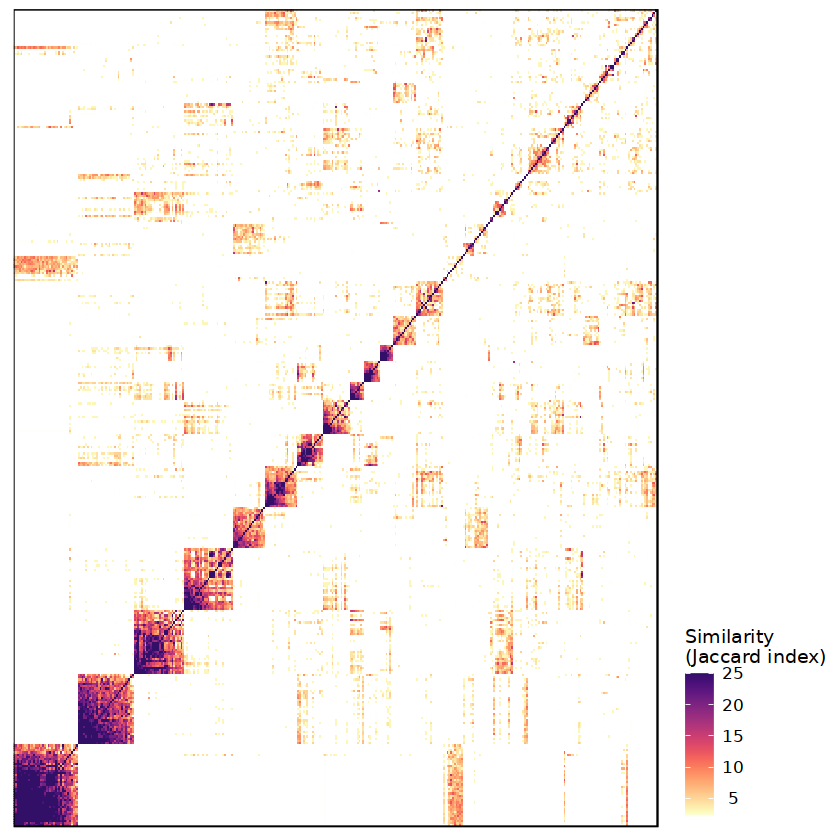

In [7]:
####  Sort Jaccard similarity plot according to new clusters:

inds_sorted <- c()

for (j in 1:length(Cluster_list)){
  
  inds_sorted <- c(inds_sorted , match(Cluster_list[[j]] , colnames(nmf_intersect_original)))
  
}
inds_new <- c(inds_sorted   ,   which(is.na( match(1:dim(nmf_intersect_original)[2],inds_sorted)))) ### clustered NMFs will appear first, and the latter are the NMFs that were not clustered

nmf_intersect_meltI_NEW <- reshape2::melt(nmf_intersect_original[inds_new,inds_new]) 

ggplot(data = nmf_intersect_meltI_NEW, aes(x=Var1, y=Var2, fill=100*value/(100-value), color=100*value/(100-value))) + 
  geom_tile() + 
  scale_color_gradient2(limits=c(2,25), low=custom_magma[1:111],  mid =custom_magma[112:222], high = custom_magma[223:333], midpoint = 13.5, oob=squish, name="Similarity\n(Jaccard index)") +                                
  scale_fill_gradient2(limits=c(2,25), low=custom_magma[1:111],  mid =custom_magma[112:222], high = custom_magma[223:333], midpoint = 13.5, oob=squish, name="Similarity\n(Jaccard index)")  +
  theme( axis.ticks = element_blank(), panel.border = element_rect(fill=F), panel.background = element_blank(),  axis.line = element_blank(), axis.text = element_text(size = 11), axis.title = element_text(size = 12), legend.title = element_text(size=11), legend.text = element_text(size = 10), legend.text.align = 0.5, legend.justification = "bottom") + 
  theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank()) + 
  theme(axis.title.y=element_blank(), axis.text.y=element_blank(), axis.ticks.y=element_blank()) + 
  guides(fill = guide_colourbar(barheight = 4, barwidth = 1))

In [8]:
nmf_intersect_meltI_NEW

Var1,Var2,value
<fct>,<fct>,<int>
T19-90673_577AAL_section_2_rank2_10_nruns10.RDS.7.1,T19-90673_577AAL_section_2_rank2_10_nruns10.RDS.7.1,50
VUMC17_healthy_rank2_10_nruns10.RDS.5.3,T19-90673_577AAL_section_2_rank2_10_nruns10.RDS.7.1,26
P-6253_S-8498_Multiome_rank2_10_nruns10.RDS.2.1,T19-90673_577AAL_section_2_rank2_10_nruns10.RDS.7.1,21
T20-90239_175AAA_rank2_10_nruns10.RDS.4.3,T19-90673_577AAL_section_2_rank2_10_nruns10.RDS.7.1,20
T20-01237_291AAN_rank2_10_nruns10.RDS.4.4,T19-90673_577AAL_section_2_rank2_10_nruns10.RDS.7.1,23
T21-90868_448AAQ_rank2_10_nruns10.RDS.5.1,T19-90673_577AAL_section_2_rank2_10_nruns10.RDS.7.1,20
T21-90517_099AAQ_rank2_10_nruns10.RDS.10.6,T19-90673_577AAL_section_2_rank2_10_nruns10.RDS.7.1,16
T21-90813_MIMIC006_rank2_10_nruns10.RDS.3.2,T19-90673_577AAL_section_2_rank2_10_nruns10.RDS.7.1,19
T22-90003_MIMIC014_rank2_10_nruns10.RDS.3.3,T19-90673_577AAL_section_2_rank2_10_nruns10.RDS.7.1,23


In [9]:
length(unique(nmf_intersect_meltI_NEW$Var1))

[1] 358

In [10]:
MP_list <-  do.call(cbind, MP_list)
MP_list

MP_1,MP_2,MP_3,MP_4,MP_5,MP_6,MP_7,MP_8,MP_9,MP_10,MP_11,MP_12,MP_13
DIAPH3,ACTG1,GBE1,RIPOR2,CTNND2,DSCAM,CCL3,F13A1,MYO1E,ANKUB1,CHORDC1,NBEA,JAZF1
CENPK,ATP5F1E,HK2,FCN1,NPAS3,NAV3,CD83,MRC1,GAS7,SLC35G2,HSPD1,RFX3,MEF2C
POLQ,C1QC,PAM,GLT1D1,LSAMP,FOXP2,NR4A1,COLEC12,GPNMB,ATP8B1,HSPH1,CLASP2,PCNX2
KNL1,CST3,CD109,PLCB1,MAP2,SYNDIG1,CCL4,LYVE1,LPL,FAM177B,BAG3,MSRA,AOAH
MELK,FAU,NDRG1,SLCO3A1,ADGRL3,HS3ST4,NR4A2,CD163,ASAP1,P2RY13,CACYBP,PHF14,EPB41L2
TOP2A,PTMA,TNS1,SVIL,RORA,CACNA1D,CCL4L2,DAPK1,GLDN,PLAT,DNAJB1,CAMTA1,PRKN
BRIP1,CD63,FNIP2,VCAN,GPM6A,MCF2L,EGR3,SELENOP,HIVEP1,PTPRB,DNAJB4,CASK,ZDHHC14
CIT,FTL,GPNMB,MEGF9,LRP1B,RASGEF1C,IRAK2,THRB,MITF,SHOC1,HSPA1A,GAB1,BLNK
RRM2,S100A11,PLIN2,FYN,PCDH9,TLN2,NFKBID,CD163L1,PTPRG,C11ORF65,HSPA1B,MAP4K5,CSGALNACT1
DTL,CD81,ADCY3,TMTC2,CADM2,WIPF3,CCL3L1,MCTP1,RGCC,MCF2L2,HSPB1,RUFY3,CTTNBP2


In [11]:
saveRDS(nmf_intersect_meltI_NEW, 'data/nmf_intersect_myeloid_nomt_noribo.rds')

In [12]:
saveRDS(MP_list, 'data/robust_NMF_programs_myeloid_nomt_noribo.rds')